# 01 - Análise Exploratória (EDA)

Primeira etapa da auditoria: conhecer os dados antes de qualquer modelo.

**Regra do jogo:** neste notebook usamos apenas o `obras.csv`, a versão SEM o gabarito de anomalias. A ideia é trabalhar como um auditor de verdade trabalharia: sem saber onde estão os problemas. Só no final damos uma espiada no gabarito para conferir se a estatística está no caminho certo.

O que vamos fazer:
1. Primeira leitura dos dados (`head`, `info`, `describe`)
2. Média vs. mediana e o efeito da assimetria
3. Distribuições com histogramas
4. Boxplots e a primeira visão dos outliers
5. Peer groups: comparar o comparável
6. Correlação entre variáveis
7. Primeira detecção: z-score e IQR

## Conclusões

1. Os dados financeiros são assimétricos à direita, então mediana e IQR são referências mais confiáveis que média e desvio.
2. Comparação global gera falso positivo em massa; peer group por tipo de empreendimento resolve.
3. Z-score e IQR, mesmo simples, já capturam boa parte das anomalias de custo olhando UM único indicador.
4. O que ficou de fora (prazo, produtividade, aditivos) precisa de indicadores específicos, e é exatamente isso que a Fase 2 constrói no `02_features.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Deixa as tabelas mais legíveis
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# O notebook roda de dentro da pasta notebooks/, por isso o ../
df = pd.read_csv("../data/raw/obras.csv")

print(f"{df.shape[0]} obras, {df.shape[1]} colunas")
df.head()

2000 obras, 17 colunas


,id_obra,cidade,uf,tipo_empreendimento,empresa_responsavel,area_construida_m2,valor_contratado,valor_aditivos,valor_executado,valor_materiais,valor_mao_de_obra,valor_compras,qtd_funcionarios,prazo_previsto_dias,prazo_realizado_dias,qtd_medicoes,qtd_fornecedores
0,1000,Curitiba,PR,residencial_popular,Construtora Planalto,"4,338.00","8,828,442.43","83,143.93","13,441,699.52","7,461,670.43","2,915,964.29","7,830,993.01",141,647,719,23,15
1,1001,Campinas,SP,residencial_padrao,Estrutural Engenharia,"3,766.00","10,594,957.06","587,580.20","10,860,855.05","6,355,099.13","3,785,032.13","6,637,609.53",119,539,1127,37,13
2,1002,Uberlandia,MG,industrial,Construtora Serrana,"3,579.00","22,803,453.02","1,557,587.47","25,926,223.41","13,837,950.62","8,675,762.61","14,192,019.75",93,518,539,17,11
3,1003,Sao Paulo,SP,residencial_padrao,Alfa Construcoes,"4,127.00","14,586,734.48","1,214,605.58","15,246,146.47","8,716,620.94","5,031,757.51","9,213,161.85",115,668,747,24,15
4,1004,Uberlandia,MG,industrial,Estrutural Engenharia,"3,445.00","22,627,309.14","1,595,599.50","27,943,440.40","12,743,453.17","13,176,109.21","13,275,437.96",168,649,731,24,8


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_obra               2000 non-null   int64  
 1   cidade                2000 non-null   str    
 2   uf                    2000 non-null   str    
 3   tipo_empreendimento   2000 non-null   str    
 4   empresa_responsavel   2000 non-null   str    
 5   area_construida_m2    2000 non-null   float64
 6   valor_contratado      2000 non-null   float64
 7   valor_aditivos        2000 non-null   float64
 8   valor_executado       2000 non-null   float64
 9   valor_materiais       2000 non-null   float64
 10  valor_mao_de_obra     2000 non-null   float64
 11  valor_compras         2000 non-null   float64
 12  qtd_funcionarios      2000 non-null   int64  
 13  prazo_previsto_dias   2000 non-null   int64  
 14  prazo_realizado_dias  2000 non-null   int64  
 15  qtd_medicoes          2000 non-n

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id_obra,"2,000.00","1,999.50",577.49,"1,000.00","1,499.75","1,999.50","2,499.25","2,999.00"
area_construida_m2,"2,000.00","3,407.01","1,846.99",427.00,"2,176.50","3,026.50","4,167.50","15,073.00"
valor_contratado,"2,000.00","12,942,141.29","9,181,680.96","815,014.98","6,407,204.60","10,522,127.57","16,756,150.42","72,620,561.70"
valor_aditivos,"2,000.00","730,299.85","1,016,793.95",150.71,"201,783.09","468,949.53","938,987.40","24,687,183.73"
valor_executado,"2,000.00","13,862,520.40","9,977,732.52","873,598.13","6,784,872.36","11,245,259.06","17,915,682.02","77,657,515.59"
valor_materiais,"2,000.00","7,572,097.31","5,500,951.42","546,430.07","3,680,648.52","6,095,852.25","9,833,771.65","42,311,817.89"
valor_mao_de_obra,"2,000.00","4,842,329.99","3,639,088.31","305,299.97","2,301,240.16","3,851,639.92","6,217,555.12","37,211,739.68"
valor_compras,"2,000.00","7,952,297.52","5,792,423.69","552,561.54","3,882,420.24","6,430,414.32","10,312,967.69","44,769,802.81"
qtd_funcionarios,"2,000.00",101.68,65.16,12.00,61.75,86.00,123.00,943.00
prazo_previsto_dias,"2,000.00",575.36,321.44,120.00,356.00,505.50,709.00,"2,724.00"


In [5]:
for coluna in ["area_construida_m2", "valor_contratado", "valor_executado"]:
    media = df[coluna].mean()
    mediana = df[coluna].median()
    assimetria = df[coluna].skew()
    print(f"{coluna}")
    print(f"  média:    {media:>15,.0f}")
    print(f"  mediana:  {mediana:>15,.0f}")
    print(f"  skew:     {assimetria:>15.2f}")
    print()

area_construida_m2
  média:              3,407
  mediana:            3,026
  skew:                1.74

valor_contratado
  média:         12,942,141
  mediana:       10,522,128
  skew:                1.85

valor_executado
  média:         13,862,520
  mediana:       11,245,259
  skew:                1.89



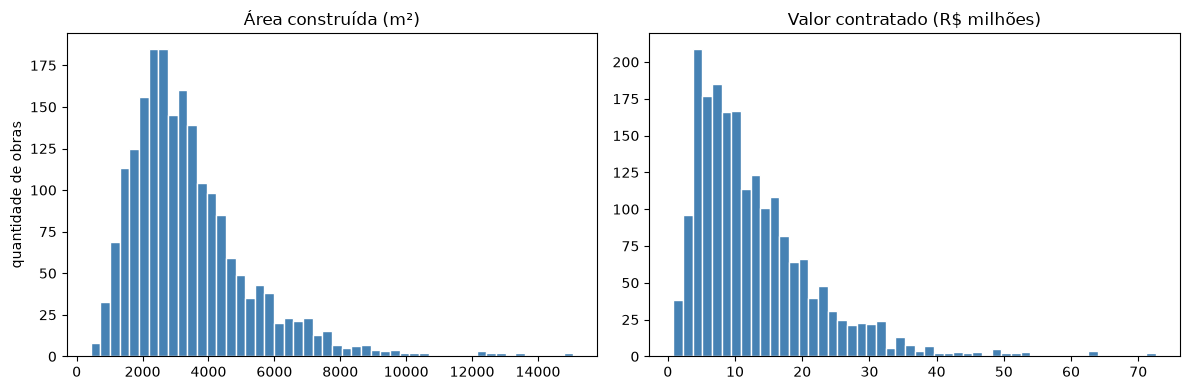

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].hist(df["area_construida_m2"], bins=50, color="steelblue", edgecolor="white")
eixos[0].set_title("Área construída (m²)")
eixos[0].set_ylabel("quantidade de obras")

eixos[1].hist(df["valor_contratado"] / 1e6, bins=50, color="steelblue", edgecolor="white")
eixos[1].set_title("Valor contratado (R$ milhões)")

plt.tight_layout()
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_14724\1277360465.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["custo_por_m2"], vert=False)


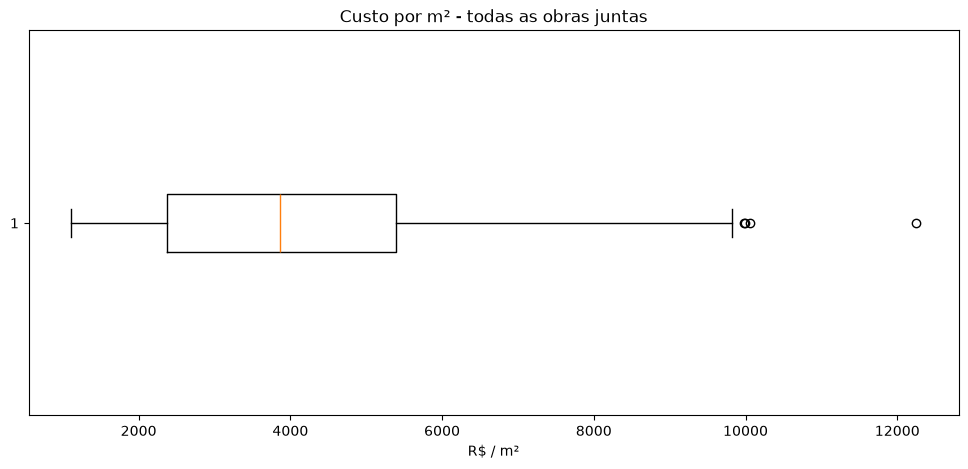

In [9]:
# Nosso primeiro indicador derivado (a Fase 2 vai criar vários outros)
df["custo_por_m2"] = df["valor_executado"] / df["area_construida_m2"]

plt.figure(figsize=(12, 5))
plt.boxplot(df["custo_por_m2"], vert=False)
plt.title("Custo por m² - todas as obras juntas")
plt.xlabel("R$ / m²")
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_14724\4122455562.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dados_por_tipo, tick_labels=tipos, vert=False)


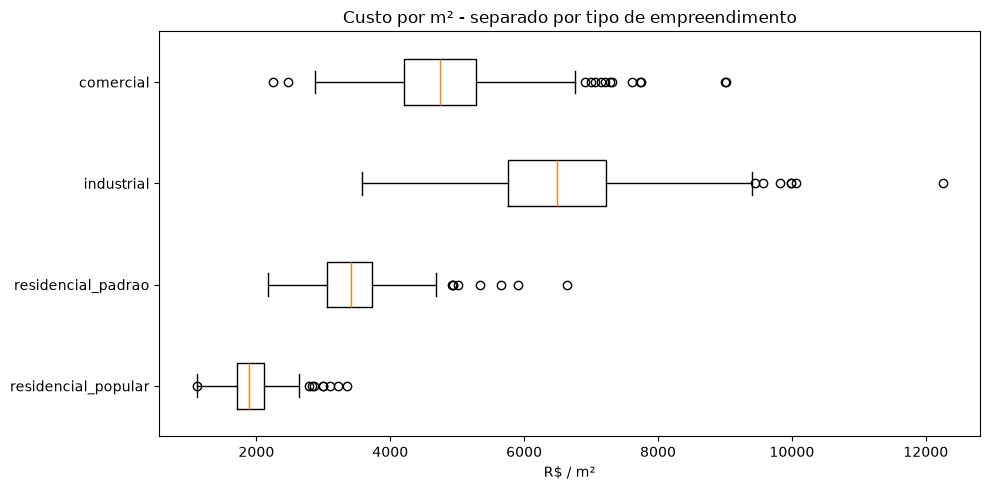

In [10]:
tipos = df["tipo_empreendimento"].unique()
dados_por_tipo = [df.loc[df["tipo_empreendimento"] == t, "custo_por_m2"] for t in tipos]

plt.figure(figsize=(10, 5))
plt.boxplot(dados_por_tipo, tick_labels=tipos, vert=False)
plt.title("Custo por m² - separado por tipo de empreendimento")
plt.xlabel("R$ / m²")
plt.tight_layout()
plt.show()

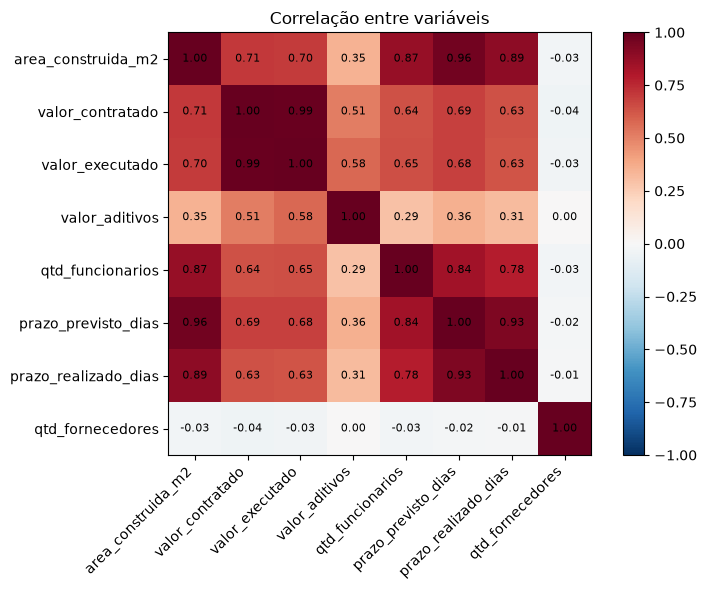

In [11]:
colunas_numericas = [
    "area_construida_m2", "valor_contratado", "valor_executado",
    "valor_aditivos", "qtd_funcionarios", "prazo_previsto_dias",
    "prazo_realizado_dias", "qtd_fornecedores",
]

matriz = df[colunas_numericas].corr()

fig, eixo = plt.subplots(figsize=(8, 6))
imagem = eixo.imshow(matriz, cmap="RdBu_r", vmin=-1, vmax=1)
eixo.set_xticks(range(len(colunas_numericas)))
eixo.set_yticks(range(len(colunas_numericas)))
eixo.set_xticklabels(colunas_numericas, rotation=45, ha="right")
eixo.set_yticklabels(colunas_numericas)

# Escreve o valor dentro de cada célula
for i in range(len(colunas_numericas)):
    for j in range(len(colunas_numericas)):
        eixo.text(j, i, f"{matriz.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(imagem)
plt.title("Correlação entre variáveis")
plt.tight_layout()
plt.show()

In [12]:
def calcular_zscore_por_grupo(df, coluna, grupo):
    """Calcula o z-score de cada obra em relação ao seu próprio grupo."""
    media_do_grupo = df.groupby(grupo)[coluna].transform("mean")
    desvio_do_grupo = df.groupby(grupo)[coluna].transform("std")
    return (df[coluna] - media_do_grupo) / desvio_do_grupo

df["z_custo_m2"] = calcular_zscore_por_grupo(df, "custo_por_m2", "tipo_empreendimento")

df["flag_zscore"] = df["z_custo_m2"].abs() > 3

print(f"Obras flagradas pelo z-score (|z| > 3): {df['flag_zscore'].sum()}")
df.loc[df["flag_zscore"], ["id_obra", "tipo_empreendimento", "custo_por_m2", "z_custo_m2"]] \
  .sort_values("z_custo_m2", ascending=False).head(10)

Obras flagradas pelo z-score (|z| > 3): 19


,id_obra,tipo_empreendimento,custo_por_m2,z_custo_m2
370,1370,residencial_padrao,"6,641.44",5.87
713,1713,industrial,"12,252.63",4.98
410,1410,comercial,"9,021.30",4.77
1045,2045,comercial,"9,004.46",4.75
658,1658,residencial_popular,"3,361.05",4.60
385,1385,residencial_padrao,"5,907.29",4.53
162,1162,residencial_popular,"3,219.68",4.15
1736,2736,residencial_padrao,"5,660.93",4.07
0,1000,residencial_popular,"3,098.59",3.77
72,1072,residencial_padrao,"5,341.23",3.49


In [13]:
def calcular_flag_iqr_por_grupo(df, coluna, grupo):
    """Marca True para obras fora da cerca de Tukey dentro do seu grupo."""
    q1 = df.groupby(grupo)[coluna].transform(lambda x: x.quantile(0.25))
    q3 = df.groupby(grupo)[coluna].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    limite_inferior = q1 - 1.5 * iqr
    return (df[coluna] > limite_superior) | (df[coluna] < limite_inferior)

df["flag_iqr"] = calcular_flag_iqr_por_grupo(df, "custo_por_m2", "tipo_empreendimento")

print(f"Obras flagradas pelo IQR: {df['flag_iqr'].sum()}")
print(f"Flagradas pelos dois métodos: {(df['flag_zscore'] & df['flag_iqr']).sum()}")

Obras flagradas pelo IQR: 38
Flagradas pelos dois métodos: 19


In [14]:
gabarito = pd.read_csv("../data/raw/obras_gabarito.csv")[["id_obra", "anomalia"]]
df_avaliacao = df.merge(gabarito, on="id_obra")

total_custo_inflado = (df_avaliacao["anomalia"] == "custo_inflado").sum()

pegas_zscore = ((df_avaliacao["anomalia"] == "custo_inflado") & df_avaliacao["flag_zscore"]).sum()
pegas_iqr = ((df_avaliacao["anomalia"] == "custo_inflado") & df_avaliacao["flag_iqr"]).sum()

print(f"Anomalias de custo inflado plantadas: {total_custo_inflado}")
print(f"Encontradas pelo z-score: {pegas_zscore} ({pegas_zscore/total_custo_inflado:.0%})")
print(f"Encontradas pelo IQR:     {pegas_iqr} ({pegas_iqr/total_custo_inflado:.0%})")

# E o outro lado da moeda: quantas obras normais foram flagradas sem motivo?
falsos_positivos_iqr = (df_avaliacao["flag_iqr"] & (df_avaliacao["anomalia"] == "nenhuma")).sum()
print(f"\nFalsos positivos do IQR (obras normais flagradas): {falsos_positivos_iqr}")

Anomalias de custo inflado plantadas: 31
Encontradas pelo z-score: 13 (42%)
Encontradas pelo IQR:     16 (52%)

Falsos positivos do IQR (obras normais flagradas): 7
